In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from tensorflow import keras
from tensorflow.keras import layers
import time

print("✅ Libraries imported")

✅ Libraries imported


In [5]:
df = pd.read_csv('bus_route_travel_time.csv')
print(f"Dataset shape: {df.shape}")
print(f"Target: total_time_minutes")
df.head()

Dataset shape: (2000, 41)
Target: total_time_minutes


,route_id,school_id,school_name,bus_id,driver_id,date,year,month,day,day_of_week,...,bus_maintenance_score,occupancy_rate,school_lat,school_lon,avg_stop_lat,avg_stop_lon,total_time_minutes,avg_speed_kmh,time_per_stop_minutes,time_per_km_minutes
0,ROUTE_00001,SCH_003,Private School C,BUS_027,DRV_037,2024-04-12,2024,4,12,4,...,4.93,1.00,3.20,101.65,3.1741,101.6899,335.29,40.19,22.35,1.49
1,ROUTE_00002,SCH_001,International School A,BUS_027,DRV_022,2024-08-05,2024,8,5,0,...,4.63,1.00,3.15,101.68,3.1822,101.6754,802.47,10.60,72.95,5.66
2,ROUTE_00003,SCH_001,International School A,BUS_014,DRV_039,2024-10-25,2024,10,25,4,...,2.17,1.00,3.15,101.68,3.1374,101.7054,1497.70,9.60,88.10,6.25
3,ROUTE_00004,SCH_003,Private School C,BUS_023,DRV_011,2024-03-16,2024,3,16,5,...,3.20,1.00,3.20,101.65,3.1898,101.7064,331.67,31.77,20.73,1.89
4,ROUTE_00005,SCH_002,National School B,BUS_006,DRV_042,2024-12-25,2024,12,25,2,...,3.94,0.84,3.12,101.70,3.2055,101.6812,516.86,11.77,73.84,5.10


Target variable statistics:
count    2000.000000
mean      695.815085
std       459.125144
min        56.360000
25%       375.220000
50%       584.035000
75%       891.637500
max      3406.080000
Name: total_time_minutes, dtype: float64


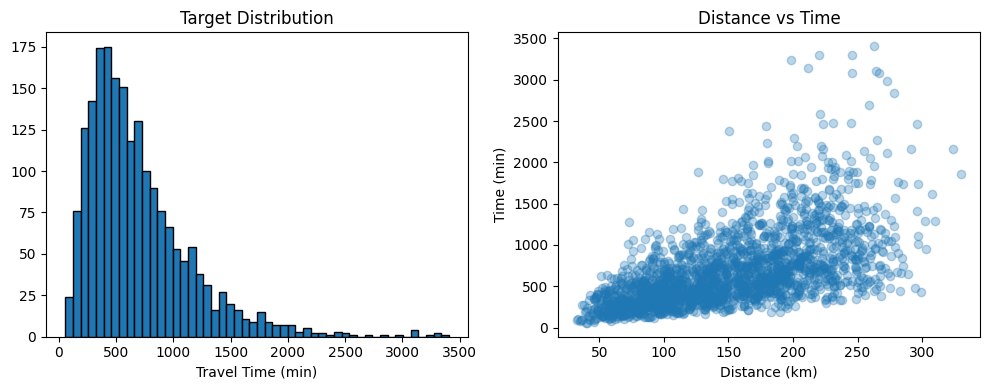

In [7]:
# Basic stats
print("Target variable statistics:")
print(df['total_time_minutes'].describe())

# Plot distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['total_time_minutes'], bins=50, edgecolor='black')
plt.xlabel('Travel Time (min)')
plt.title('Target Distribution')

plt.subplot(1, 2, 2)
plt.scatter(df['total_distance_km'], df['total_time_minutes'], alpha=0.3)
plt.xlabel('Distance (km)')
plt.ylabel('Time (min)')
plt.title('Distance vs Time')
plt.tight_layout()
import os
os.makedirs('outputs', exist_ok=True)

plt.savefig('outputs/01_eda.png', dpi=300)
plt.savefig('outputs/01_eda.png', dpi=300)
plt.show()

In [8]:
# Drop columns we don't need for prediction
drop_cols = ['route_id', 'date', 'school_name', 'bus_id', 'driver_id',
             'avg_speed_kmh', 'time_per_stop_minutes', 'time_per_km_minutes']

df_clean = df.drop(columns=drop_cols)
print(f"After dropping: {df_clean.shape}")

After dropping: (2000, 33)


In [9]:
# Find categorical columns
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {cat_cols}")

# Encode them
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])

print("✅ Categorical variables encoded")

Categorical columns: ['school_id', 'season', 'route_zone', 'road_type', 'traffic_conditions', 'weather']
✅ Categorical variables encoded


In [10]:
# Separate X and y
X = df_clean.drop(columns=['total_time_minutes'])
y = df_clean['total_time_minutes']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1600, 32), Test: (400, 32)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled")

✅ Features scaled


In [12]:
print("Training XGBoost...")
start = time.time()

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)
xgb_time = time.time() - start

print(f"✅ Trained in {xgb_time:.2f}s")

Training XGBoost...
✅ Trained in 6.95s


In [13]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Metrics
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print(f"  RMSE: {xgb_rmse:.4f}")
print(f"  MAE:  {xgb_mae:.4f}")
print(f"  R²:   {xgb_r2:.4f}")

XGBoost Results:
  RMSE: 143.6084
  MAE:  85.6417
  R²:   0.8942


In [14]:
print("Training Neural Network...")
start = time.time()

nn_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

nn_time = time.time() - start
print(f"✅ Trained in {nn_time:.2f}s")

Training Neural Network...
✅ Trained in 36.40s


In [15]:
# Predictions
y_pred_nn = nn_model.predict(X_test_scaled, verbose=0).flatten()

# Metrics
nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_r2 = r2_score(y_test, y_pred_nn)

print("Neural Network Results:")
print(f"  RMSE: {nn_rmse:.4f}")
print(f"  MAE:  {nn_mae:.4f}")
print(f"  R²:   {nn_r2:.4f}")

Neural Network Results:
  RMSE: 295.4667
  MAE:  213.8522
  R²:   0.5520


In [16]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'Neural Network'],
    'RMSE': [xgb_rmse, nn_rmse],
    'MAE': [xgb_mae, nn_mae],
    'R²': [xgb_r2, nn_r2],
    'Training Time (s)': [xgb_time, nn_time]
})

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(comparison.to_string(index=False))

# Determine winner
winner = 'XGBoost' if xgb_r2 > nn_r2 else 'Neural Network'
print(f"\n🏆 Winner: {winner} (Higher R²)")


MODEL COMPARISON
         Model       RMSE        MAE       R²  Training Time (s)
       XGBoost 143.608430  85.641725 0.894178           6.953277
Neural Network 295.466678 213.852155 0.552045          36.395076

🏆 Winner: XGBoost (Higher R²)


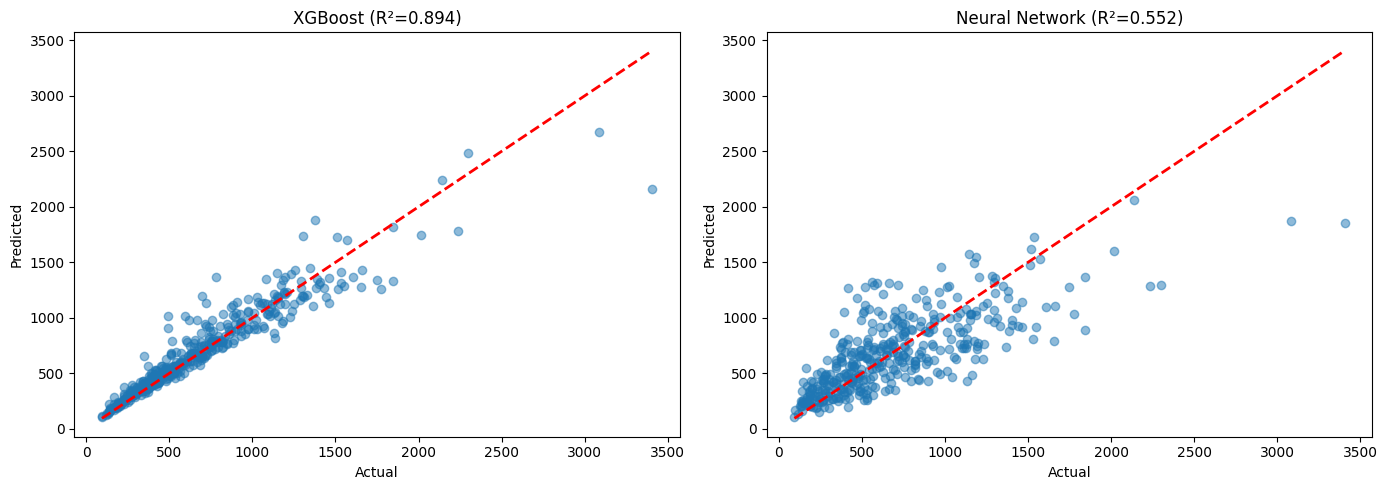

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost
axes[0].scatter(y_test, y_pred_xgb, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'XGBoost (R²={xgb_r2:.3f})')

# Neural Network
axes[1].scatter(y_test, y_pred_nn, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Neural Network (R²={nn_r2:.3f})')

plt.tight_layout()
plt.savefig('outputs/02_predictions.png', dpi=300)
plt.show()

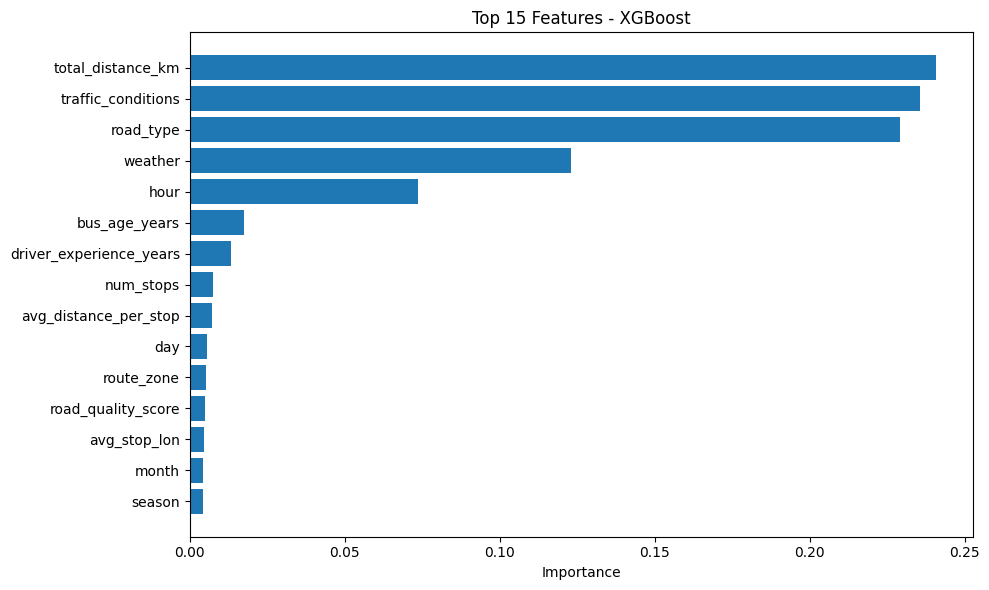

In [18]:
# XGBoost feature importance
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Features - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/03_feature_importance.png', dpi=300)
plt.show()

In [20]:
# Save comparison
comparison.to_csv('outputs/model_comparison.csv', index=False)

# Save models
os.makedirs('models', exist_ok=True)
xgb_model.save_model('models/xgboost_model.json')
nn_model.save('models/neural_network_model.h5')

print("✅ Results and models saved")

✅ Results and models saved


In [21]:
# Generate sample bus stops for one route
np.random.seed(42)

stops_data = pd.DataFrame({
    'stop_id': [f'S{i:02d}' for i in range(10)],
    'lat': np.random.uniform(3.10, 3.20, 10),
    'lon': np.random.uniform(101.65, 101.75, 10),
    'students': np.random.randint(3, 12, 10)
})

school_location = {'lat': 3.15, 'lon': 101.70, 'name': 'Target School'}

print("Bus Stops to Optimize:")
print(stops_data)
print(f"\nSchool Location: {school_location}")

Bus Stops to Optimize:
  stop_id       lat         lon  students
0     S00  3.137454  101.652058         5
1     S01  3.195071  101.746991         9
2     S02  3.173199  101.733244         6
3     S03  3.159866  101.671234        11
4     S04  3.115602  101.668182         5
5     S05  3.115599  101.668340         7
6     S06  3.105808  101.680424         5
7     S07  3.186618  101.702476         9
8     S08  3.160112  101.693195         7
9     S09  3.170807  101.679123        11

School Location: {'lat': 3.15, 'lon': 101.7, 'name': 'Target School'}


In [22]:
def calculate_route_distance(route_sequence, stops, school):
    """Calculate total distance for a route sequence"""
    total_dist = 0
    for i in range(len(route_sequence) - 1):
        stop1 = stops.iloc[route_sequence[i]]
        stop2 = stops.iloc[route_sequence[i+1]]
        dist = np.sqrt((stop2['lat'] - stop1['lat'])**2 +
                       (stop2['lon'] - stop1['lon'])**2)
        total_dist += dist

    # Distance from last stop to school
    last_stop = stops.iloc[route_sequence[-1]]
    total_dist += np.sqrt((school['lat'] - last_stop['lat'])**2 +
                          (school['lon'] - last_stop['lon'])**2)
    return total_dist

def predict_route_time(route_sequence, stops, ml_model, scaler):
    """Use ML model to predict travel time"""
    # Create features for this route
    total_dist = calculate_route_distance(route_sequence, stops, school_location)
    num_stops = len(route_sequence)
    total_students = stops.iloc[route_sequence]['students'].sum()

    # Simple feature vector (use same features as training)
    features = np.array([[
        2024, 6, 15, 1, 0, 7, 30, 0, 1,  # date/time features
        num_stops, total_dist, total_students,
        total_students/num_stops, total_dist/num_stops,
        50, 3.5, 25, 5, 35, 1, 3.15, 101.70  # other features
    ]])

    # Pad to match training features
    if features.shape[1] < X_train.shape[1]:
        padding = np.zeros((1, X_train.shape[1] - features.shape[1]))
        features = np.hstack([features, padding])

    features_scaled = scaler.transform(features)
    predicted_time = ml_model.predict(features_scaled)[0]

    return predicted_time

print("✅ Route evaluation functions created")

✅ Route evaluation functions created


In [23]:
def genetic_algorithm_optimize(stops, school, population_size=50, generations=100):
    """Find optimal route sequence using Genetic Algorithm"""
    n_stops = len(stops)

    # Initialize population (random routes)
    population = [np.random.permutation(n_stops).tolist() for _ in range(population_size)]

    best_route = None
    best_distance = float('inf')
    history = []

    for gen in range(generations):
        # Evaluate fitness (lower distance = better)
        fitness_scores = []
        for route in population:
            dist = calculate_route_distance(route, stops, school)
            fitness_scores.append(dist)

        # Track best
        gen_best_idx = np.argmin(fitness_scores)
        gen_best_dist = fitness_scores[gen_best_idx]

        if gen_best_dist < best_distance:
            best_distance = gen_best_dist
            best_route = population[gen_best_idx].copy()

        history.append(best_distance)

        # Selection (tournament)
        new_population = []
        for _ in range(population_size):
            # Select 2 parents
            idx1, idx2 = np.random.choice(population_size, 2, replace=False)
            parent = population[idx1] if fitness_scores[idx1] < fitness_scores[idx2] else population[idx2]
            new_population.append(parent)

        # Crossover and mutation
        for i in range(0, population_size-1, 2):
            if np.random.random() < 0.8:  # Crossover probability
                # Order crossover
                point = np.random.randint(1, n_stops-1)
                child1 = new_population[i][:point] + [x for x in new_population[i+1] if x not in new_population[i][:point]]
                new_population[i] = child1

        # Mutation (swap two stops)
        for i in range(population_size):
            if np.random.random() < 0.2:  # Mutation probability
                idx1, idx2 = np.random.choice(n_stops, 2, replace=False)
                new_population[i][idx1], new_population[i][idx2] = new_population[i][idx2], new_population[i][idx1]

        population = new_population

        if gen % 20 == 0:
            print(f"Generation {gen}: Best distance = {best_distance:.4f}")

    return best_route, best_distance, history

print("✅ Genetic Algorithm ready")

✅ Genetic Algorithm ready


In [24]:
print("="*60)
print("RUNNING ROUTE OPTIMIZATION")
print("="*60)

# Run GA
optimized_route, optimized_dist, ga_history = genetic_algorithm_optimize(
    stops_data, school_location, population_size=50, generations=100
)

print(f"\n✅ Optimization Complete!")
print(f"Optimized route sequence: {optimized_route}")
print(f"Optimized distance: {optimized_dist:.4f}")

# Predict time for optimized route
optimized_time = predict_route_time(optimized_route, stops_data, xgb_model, scaler)
print(f"Predicted travel time: {optimized_time:.2f} minutes")

# Compare with random route
random_route = list(range(len(stops_data)))
random_dist = calculate_route_distance(random_route, stops_data, school_location)
random_time = predict_route_time(random_route, stops_data, xgb_model, scaler)

print(f"\nComparison:")
print(f"  Random route distance: {random_dist:.4f}")
print(f"  Random route time: {random_time:.2f} minutes")
print(f"  Improvement: {((random_dist - optimized_dist) / random_dist * 100):.1f}%")

RUNNING ROUTE OPTIMIZATION
Generation 0: Best distance = 0.4061
Generation 20: Best distance = 0.2586
Generation 40: Best distance = 0.2586
Generation 60: Best distance = 0.2396
Generation 80: Best distance = 0.2393

✅ Optimization Complete!
Optimized route sequence: [1, 2, 7, 8, 9, 3, 0, 4, 5, 6]
Optimized distance: 0.2393
Predicted travel time: 616.35 minutes

Comparison:
  Random route distance: 0.4194
  Random route time: 616.35 minutes
  Improvement: 42.9%


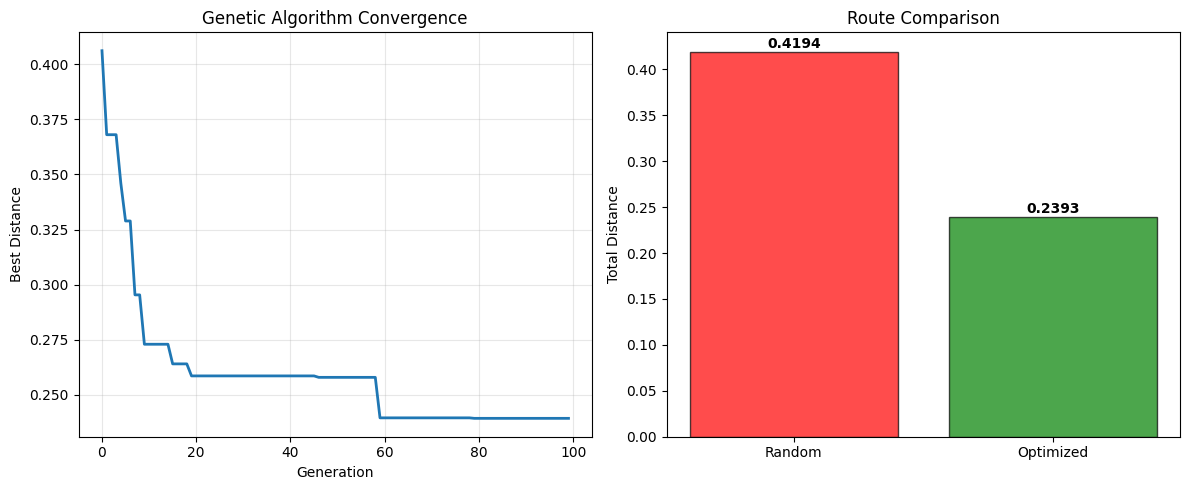

✅ Optimization visualization complete


In [25]:
plt.figure(figsize=(12, 5))

# Plot 1: GA convergence
plt.subplot(1, 2, 1)
plt.plot(ga_history, linewidth=2)
plt.xlabel('Generation')
plt.ylabel('Best Distance')
plt.title('Genetic Algorithm Convergence')
plt.grid(True, alpha=0.3)

# Plot 2: Route comparison
plt.subplot(1, 2, 2)
routes = ['Random', 'Optimized']
distances = [random_dist, optimized_dist]
colors = ['red', 'green']
bars = plt.bar(routes, distances, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Total Distance')
plt.title('Route Comparison')

for bar, dist in zip(bars, distances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{dist:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/04_optimization.png', dpi=300)
plt.show()

print("✅ Optimization visualization complete")

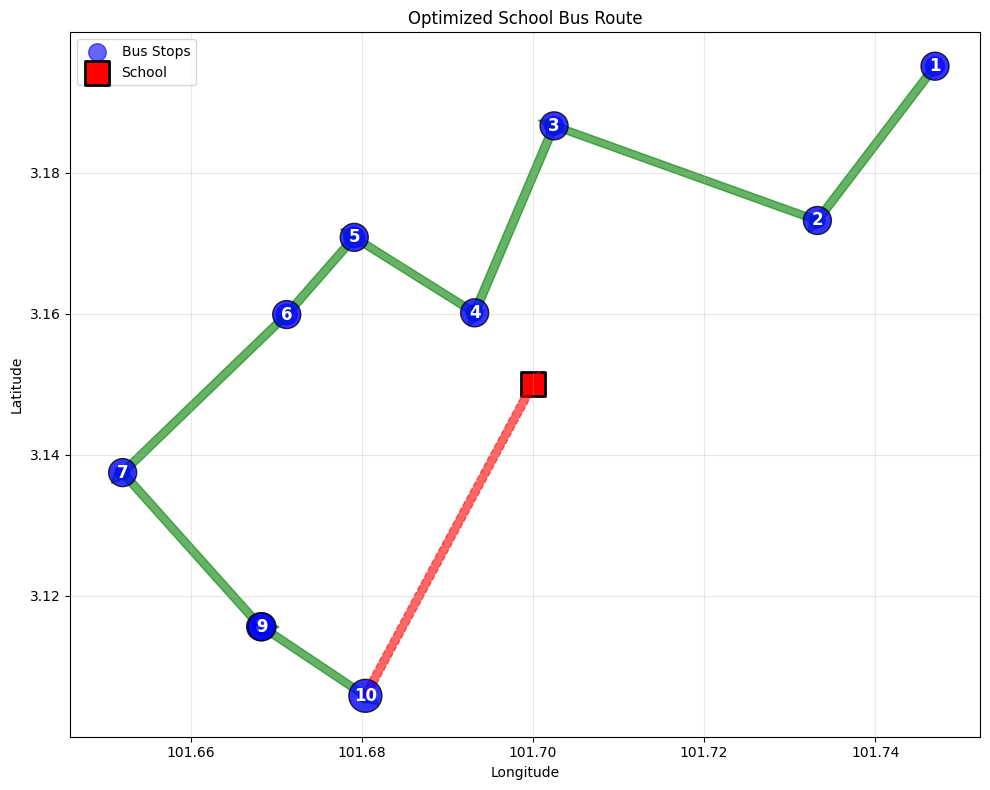

✅ Route map created


In [26]:
# Plot optimized route
plt.figure(figsize=(10, 8))

# Plot all stops
plt.scatter(stops_data['lon'], stops_data['lat'],
           s=stops_data['students']*20, alpha=0.6, c='blue', label='Bus Stops')

# Plot school
plt.scatter(school_location['lon'], school_location['lat'],
           s=300, marker='s', c='red', label='School', edgecolors='black', linewidth=2)

# Draw optimized route
for i in range(len(optimized_route)):
    stop = stops_data.iloc[optimized_route[i]]
    plt.text(stop['lon'], stop['lat'], f"{i+1}", fontsize=12,
            ha='center', va='center', fontweight='bold', color='white',
            bbox=dict(boxstyle='circle', facecolor='blue', alpha=0.8))

    if i < len(optimized_route) - 1:
        next_stop = stops_data.iloc[optimized_route[i+1]]
        plt.arrow(stop['lon'], stop['lat'],
                 next_stop['lon'] - stop['lon'],
                 next_stop['lat'] - stop['lat'],
                 head_width=0.002, head_length=0.002, fc='green', ec='green', alpha=0.6)

# Last stop to school
last_stop = stops_data.iloc[optimized_route[-1]]
plt.arrow(last_stop['lon'], last_stop['lat'],
         school_location['lon'] - last_stop['lon'],
         school_location['lat'] - last_stop['lat'],
         head_width=0.002, head_length=0.002, fc='red', ec='red', alpha=0.6, linestyle='--')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Optimized School Bus Route')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/05_route_map.png', dpi=300)
plt.show()

print("✅ Route map created")